In [6]:
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta
import math
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

Ideas for analysis 

- [] number of events per interval and sum per category per interval 
- [] type and severity of events
- [] unique actors involved and level of involvement (measured by frequency). Map onto geo and event type analyses 
- [] geographic spread of events & geographic spread across time. Map onto event type analysis.
- [] missing values

In [2]:
dir_processed = Path('../data/processed')
dir_processed.mkdir(exist_ok=True)
dir_raw = Path('../data/raw')
dir_raw.mkdir(exist_ok=True)

In [3]:
dataset = pd.read_csv(dir_processed / 'dataset.csv')
dataset.index = dataset.index + 1

In [ ]:
['interval', 'event_type', 'count']

,event_id_cnty,event_date,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,actor2,...,admin3,location,geo_precision,source,fatalities,tags,date,interval,start date,end date
1,SYR154018,2024-12-08,1,Strategic developments,Strategic developments,Non-violent transfer of territory,Military Operations Command,NaN,Rebel group,Military Forces of Syria (2000-2024),...,Bait Jan,Bait Jan,2,Syrian Memory Project,0,NaN,2024-12-08,0,2024-12-08,2025-01-07
2,SYR154016,2024-12-08,1,Strategic developments,Strategic developments,Non-violent transfer of territory,Military Operations Command,NaN,Rebel group,Military Forces of Syria (2000-2024),...,Nashabiyeh,Nashabiyeh,2,Syrian Memory Project,0,NaN,2024-12-08,0,2024-12-08,2025-01-07
3,SYR154017,2024-12-08,1,Strategic developments,Strategic developments,Non-violent transfer of territory,JSH: Free Syrian Army,NaN,Rebel group,Military Forces of Syria (2000-2024),...,Sabe Byar,Sabe Byar,2,Syrian Memory Project,0,NaN,2024-12-08,0,2024-12-08,2025-01-07
4,SYR154019,2024-12-08,1,Strategic developments,Strategic developments,Non-violent transfer of territory,Damascus Liberation Operations Room,NaN,Rebel group,Military Forces of Syria (2000-2024),...,Qatana,Qatana,2,Syrian Memory Project,0,NaN,2024-12-08,0,2024-12-08,2025-01-07
5,SYR137757,2024-12-08,1,Strategic developments,Strategic developments,Non-violent transfer of territory,Military Operations Command,NaN,Rebel group,Military Forces of Syria (2000-2024),...,Sokhneh,Sokhneh,2,Halab Today; Telegram,0,NaN,2024-12-08,0,2024-12-08,2025-01-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16841,SYR155097,2026-07-17,1,Political violence,Battles,Armed clash,Al Sabinah Al Kubra Communal Militia (Syria),NaN,Identity militia,Al Sabinah Al Kubra Communal Militia (Syria),...,Babella,Al Sabinah Al Kubra,1,SOHR,1,NaN,2026-07-17,18,2026-06-19,2026-07-19
16842,SYR155124,2026-07-17,1,Strategic developments,Strategic developments,Change to group/activity,Military Forces of Israel (2022-),NaN,External/Other forces,NaN,...,Ash Shajara,Abdin,1,Dar'a 24; Halab Today; North Press Agency; SHA...,0,Foreign military engagement,2026-07-17,18,2026-06-19,2026-07-19
16843,SYR155125,2026-07-17,1,Strategic developments,Strategic developments,Change to group/activity,Military Forces of Israel (2022-),NaN,External/Other forces,NaN,...,Quneitra,Rweheineh,1,Dar'a 24; Sijil; SOHR,0,Foreign military engagement,2026-07-17,18,2026-06-19,2026-07-19
16844,SYR155109,2026-07-17,1,Strategic developments,Strategic developments,Arrests,Police Forces of Syria (2024-),NaN,State forces,Smugglers (Syria),...,Homs,Homs - Unspecified,3,North Press Agency; SY24; Syria TV,0,NaN,2026-07-17,18,2026-06-19,2026-07-19


In [ ]:
# dataset['year'] = dataset['date'].dt.year

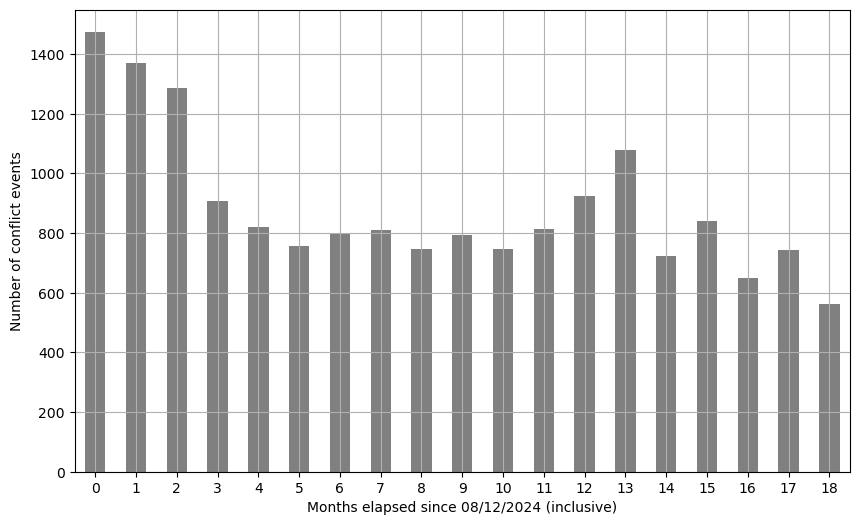

In [5]:
plot_bar = (
    dataset
    .groupby('interval')['event_type']
    .size()
    .plot.bar(
        rot=0, 
        figsize=(10,6), 
        xlabel='Months elapsed since 08/12/2024 (inclusive)', 
        ylabel='Number of conflict events', 
        color='#808080', 
        grid=True))

In [ ]:
plot_stacked = (
    dataset
    .groupby('interval', 'event_type')['event_type']
    .size()
    # .pipe(lambda s: s / s.groupby(level=0).transform('sum'))
    .plot.bar(stacked=True, rot=0, figsize=(10,6), xlabel='interval', ylabel='event_type'))

    - plotly 

In [ ]:
plot_scatter = (
    dataset
    .groupby('interval', 'event_type')['event_type']
    .size()
    .plot
)

In [ ]:
# df_first_month = df[df['interval'] == 0]
# df_first_month

"use groupby to look at number of events and violent events since regime transfer"

df_count_interval = dataset.groupby('interval')["sub_event_type"].size()

df_count_interval


In [62]:
df_interval_and_events = dataset[['interval','event_type', 'sub_event_type', 'date']]
df_event_count = df_interval_and_events.groupby('interval')['event_type'].size()
type(df_event_count)

pandas.Series

In [65]:
def df_index(dataframe):
    rows = len(dataframe)

    dataframe.index = range(1, rows+1)
    
    return dataframe

In [ ]:
df_interval_boundaries = dataset[['interval', 'start date', 'end date']].drop_duplicates()
df_index(df_interval_boundaries)

In [ ]:
df_events = pd.merge(df_event_count, df_interval_boundaries, on='interval')
df_events = df_events.rename(columns = {'event_type':'event count', 'start date': "interval start", 'end date': 'interval end'})
df_events.to_csv(dir_processed/'events_summary.csv', index=False)
df_events

,interval,event count,interval start,interval end
0,0,1475,2024-12-08,2025-01-07
1,1,1370,2025-01-08,2025-02-07
2,2,1285,2025-02-08,2025-03-10
3,3,909,2025-03-11,2025-04-10
4,4,820,2025-04-11,2025-05-11
5,5,758,2025-05-12,2025-06-11
6,6,798,2025-06-12,2025-07-12
7,7,809,2025-07-13,2025-08-12
8,8,746,2025-08-13,2025-09-12
9,9,795,2025-09-13,2025-10-13


In [ ]:
"function doesn't work"

df_events_test = (
    dataset
    .groupby('interval', 'event_type'),
    .agg('size'),
    .reset_index()
    )

SyntaxError: invalid syntax (3827163459.py, line 4)

In [ ]:
df_events =

In [32]:
df_events

,interval,sub_event_type,start date,end date
0,0,1475,2024-12-08,2025-01-07
1,0,1475,2024-12-08,2025-01-07
2,0,1475,2024-12-08,2025-01-07
3,0,1475,2024-12-08,2025-01-07
4,0,1475,2024-12-08,2025-01-07
...,...,...,...,...
16840,18,562,2026-06-19,2026-07-19
16841,18,562,2026-06-19,2026-07-19
16842,18,562,2026-06-19,2026-07-19
16843,18,562,2026-06-19,2026-07-19


In [ ]:
df_count_event_type = dataset.groupby("sub_event_type").size()
df_count_event_type

In [ ]:
# event_type = dataset.groupby("event_type").count()
# event_type
# event_type = dataset.groupby("event_type").size()
# event_type
event_type.reset_index(name = 'count')

In [ ]:
# event_types = dataset.groupby(['event_type', 'sub_event_type']).size() 
event_types.reset_index(name = 'count')
event_types

In [ ]:
index = [range(1,len(event_by_interval)+1)]

In [ ]:
"group interval, then event_type"

event_by_interval = pd.DataFrame(dataset.groupby(["interval", "event_type"])['event_type'].size())
event_by_interval

event_by_interval = event_by_interval.rename(columns={'interval':'interval', 'event_type':'count'})
event_by_interval = event_by_interval.rename(columns={'event_type':'event'})
event_by_interval.to_csv(dir_processed/'event_by_interval.csv', index=True)
event_by_interval.reindex(index) "doesn't reindex"
event_by_interval

In [ ]:
df_event_by_interval = pd.DataFrame([event_by_interval], columns=['interval', 'event', 'count'])
df_event_by_interval

In [ ]:
event_by_interval = (
    dataset
    .query()
    .pipe()
    .groupby()
    .apply()
)

In [ ]:
"create a bar plot of the 'event_type' column, x = interval"

plot_events_per_interval = dataset.plot.bar(x = "interval", y = 'event_type')